# 🦅 Corvus — Entrenamiento del Modelo No Supervisado
## Microservicio: `integratorProjectClustering-back-corvus`

**Algoritmo:** HDBSCAN + UMAP (reducción dimensional) + Motor Híbrido (Dense + TF-IDF)  
**Corpus:** 50 propuestas de proyectos integradores sintéticos agrupados en 10 dominios  
**Artefactos generados:**  
- `app/models/umap_50d_model.joblib` — Reductor UMAP a 50 dimensiones  
- `app/models/hdbscan_model.joblib` — Clasificador de clústeres / Océanos Azules

> Este notebook documenta el proceso completo de entrenamiento del modelo que actualmente corre en producción en Contabo.

## 1. Dependencias e Importaciones

In [1]:
# Instalar dependencias si es necesario
# !pip install sentence-transformers umap-learn hdbscan scikit-learn joblib matplotlib seaborn

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sentence_transformers import SentenceTransformer
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import normalize
import umap
import hdbscan

# Semilla aleatoria para reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('✅ Dependencias cargadas correctamente')

✅ Dependencias cargadas correctamente


## 2. Carga del Corpus (50 Proyectos)

In [2]:
# Ruta al corpus de proyectos de prueba
# Ajusta esta ruta si ejecutas el notebook desde otra ubicación
CORPUS_PATH = Path('../../../pruebas/corvus-backend-local/projectsTests')
if not CORPUS_PATH.exists():
    CORPUS_PATH = Path('projectsTests')  # fallback relativo

docs = []
labels_raw = []

for filepath in sorted(CORPUS_PATH.glob('*.md')):
    category = filepath.stem.split('_')[0]  # ej. 'edu', 'fintech', 'salud'...
    text = filepath.read_text(encoding='utf-8')
    docs.append(text)
    labels_raw.append(category)

print(f'📂 Proyectos cargados: {len(docs)}')
print(f'📊 Categorías únicas:  {sorted(set(labels_raw))}')

📂 Proyectos cargados: 65
📊 Categorías únicas:  ['agri', 'blue', 'edu', 'fintech', 'ind', 'salud']


## 3. EDA — Distribución del Corpus

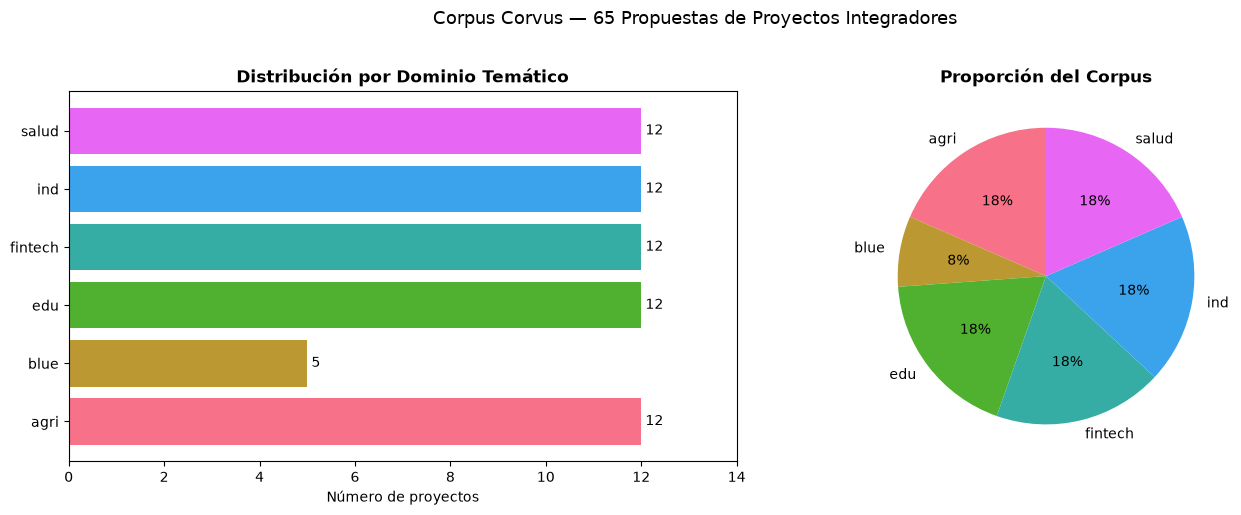

✅ Gráfica guardada: corpus_distribucion.png


In [3]:
from collections import Counter

category_counts = Counter(labels_raw)
categories = list(category_counts.keys())
counts = list(category_counts.values())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Barra de distribución
palette = sns.color_palette('husl', len(categories))
bars = ax1.barh(categories, counts, color=palette)
ax1.set_xlabel('Número de proyectos')
ax1.set_title('Distribución por Dominio Temático', fontweight='bold')
ax1.bar_label(bars, padding=3)
ax1.set_xlim(0, max(counts) + 2)

# Pastel
ax2.pie(counts, labels=categories, autopct='%1.0f%%', colors=palette, startangle=90)
ax2.set_title('Proporción del Corpus', fontweight='bold')

plt.suptitle(f'Corpus Corvus — {len(docs)} Propuestas de Proyectos Integradores', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('corpus_distribucion.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada: corpus_distribucion.png')

## 4. Preprocesamiento y Vectorización (Embeddings)

In [4]:
print('⏳ Cargando modelo SentenceTransformer (paraphrase-multilingual-MiniLM-L12-v2)...')
encoder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print('✅ Modelo cargado (vectores de 384 dimensiones)')

print('\n⏳ Vectorizando corpus...')
embeddings_raw = encoder.encode(docs, convert_to_numpy=True, show_progress_bar=True)

# Normalizar a esfera unitaria (mejora la calidad del clustering con distancia coseno)
embeddings = normalize(embeddings_raw, norm='l2')

print(f'\n✅ Embeddings generados: {embeddings.shape}  (proyectos × dimensiones)')

⏳ Cargando modelo SentenceTransformer (paraphrase-multilingual-MiniLM-L12-v2)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Modelo cargado (vectores de 384 dimensiones)

⏳ Vectorizando corpus...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]


✅ Embeddings generados: (65, 384)  (proyectos × dimensiones)


## 5. Entrenamiento — UMAP (Reducción Dimensional)

In [5]:
print('⏳ Entrenando UMAP a 50 dimensiones...')

reducer_50d = umap.UMAP(
    n_components=50,
    n_neighbors=8,
    min_dist=0.0,
    metric='cosine',
    random_state=RANDOM_SEED
)
embeddings_50d = reducer_50d.fit_transform(embeddings)

print(f'✅ UMAP 50D entrenado. Shape final: {embeddings_50d.shape}')

# Guardar artefacto
MODELS_DIR = Path('../app/models')
MODELS_DIR.mkdir(exist_ok=True)
umap_path = MODELS_DIR / 'umap_50d_model.joblib'
joblib.dump(reducer_50d, umap_path)
print(f'💾 Artefacto guardado: {umap_path}')

⏳ Entrenando UMAP a 50 dimensiones...


✅ UMAP 50D entrenado. Shape final: (65, 50)
💾 Artefacto guardado: ../app/models/umap_50d_model.joblib


## 6. Entrenamiento — HDBSCAN (Clustering No Supervisado)

In [6]:
print('⏳ Entrenando HDBSCAN...')

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=3,
    min_samples=2,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True  # Necesario para approximate_predict en inferencia
)
cluster_labels = clusterer.fit_predict(embeddings_50d)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise    = list(cluster_labels).count(-1)

print(f'\n📊 Resultados del Clustering:')
print(f'   Clústeres detectados:  {n_clusters}')
print(f'   Puntos ruido (label=-1): {n_noise}  ← candidatos a Océano Azul')
print(f'   Proyectos en clústeres:  {len(cluster_labels) - n_noise}')

# Guardar artefacto
hdbscan_path = MODELS_DIR / 'hdbscan_model.joblib'
joblib.dump(clusterer, hdbscan_path)
print(f'\n💾 Artefacto guardado: {hdbscan_path}')

⏳ Entrenando HDBSCAN...

📊 Resultados del Clustering:
   Clústeres detectados:  7
   Puntos ruido (label=-1): 3  ← candidatos a Océano Azul
   Proyectos en clústeres:  62

💾 Artefacto guardado: ../app/models/hdbscan_model.joblib


## 7. Métricas de Evaluación (No Supervisado)

In [7]:
# Solo calcular métricas en proyectos asignados a clústeres (no en ruido)
mask = cluster_labels != -1

if mask.sum() >= 2 and len(set(cluster_labels[mask])) >= 2:
    sil = silhouette_score(embeddings_50d[mask], cluster_labels[mask])
    dbi = davies_bouldin_score(embeddings_50d[mask], cluster_labels[mask])
    print(f'📐 Silhouette Score : {sil:.4f}  (rango -1 a 1; mayor es mejor, >0.3 es aceptable)')
    print(f'📐 Davies-Bouldin   : {dbi:.4f}  (menor es mejor; <1.0 es bueno)')
else:
    print('⚠️ No hay suficientes puntos en clústeres para calcular métricas globales')

# Distribución de clústeres
print(f'\n📊 Tamaño de cada clúster:')
for label in sorted(set(cluster_labels)):
    count = list(cluster_labels).count(label)
    name  = 'RUIDO (Océano Azul)' if label == -1 else f'Clúster {label}'
    bar   = '█' * count
    print(f'  {name:25s}: {bar} ({count})')

📐 Silhouette Score : 0.6516  (rango -1 a 1; mayor es mejor, >0.3 es aceptable)
📐 Davies-Bouldin   : 0.4424  (menor es mejor; <1.0 es bueno)

📊 Tamaño de cada clúster:
  RUIDO (Océano Azul)      : ███ (3)
  Clúster 0                : ████ (4)
  Clúster 1                : █████████ (9)
  Clúster 2                : ████████████ (12)
  Clúster 3                : ███████████ (11)
  Clúster 4                : ███████████████ (15)
  Clúster 5                : █████ (5)
  Clúster 6                : ██████ (6)


## 8. Visualización 2D del Mapa Semántico

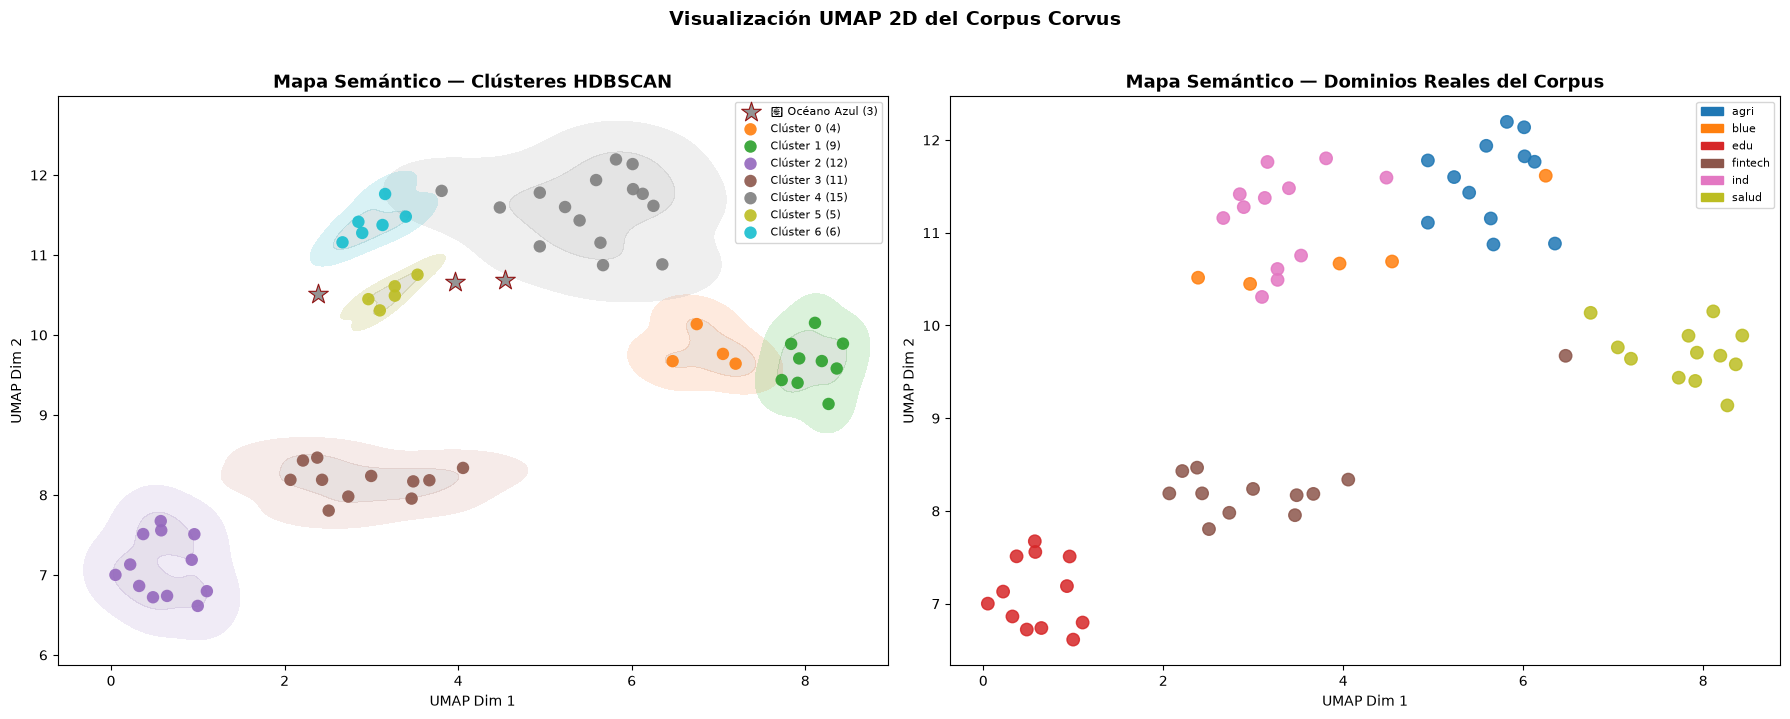

✅ Visualización guardada: mapa_semantico_2d.png


In [8]:
# Reducir a 2D solo para visualización (NO se usa en producción)
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=8,
    min_dist=0.1,
    metric='cosine',
    random_state=RANDOM_SEED
)
embeddings_2d = reducer_2d.fit_transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Coloreado por HDBSCAN cluster ---
unique_labels = sorted(set(cluster_labels))
cmap = plt.colormaps['tab10'].resampled(max(len(unique_labels), 2))

for i, lbl in enumerate(unique_labels):
    mask = cluster_labels == lbl
    color = '#888888' if lbl == -1 else cmap(i)
    marker = '*' if lbl == -1 else 'o'
    s_size = 220 if lbl == -1 else 80
    edge_col = 'darkred' if lbl == -1 else 'none'
    label_name = f'🌊 Océano Azul ({mask.sum()})' if lbl == -1 else f'Clúster {lbl} ({mask.sum()})'
    axes[0].scatter(
        embeddings_2d[mask, 0], embeddings_2d[mask, 1],
        c=[color], marker=marker, s=s_size, alpha=0.9,
        edgecolors=edge_col, linewidths=0.8, label=label_name, zorder=10
    )
    # Nubes de densidad KDE (anillos concéntricos) para clústeres con suficientes puntos
    if lbl != -1 and mask.sum() >= 4:
        try:
            import seaborn as sns
            sns.kdeplot(
                x=embeddings_2d[mask, 0], y=embeddings_2d[mask, 1],
                ax=axes[0], fill=True, color=color,
                alpha=0.18, levels=3, thresh=0.05
            )
        except Exception:
            pass

axes[0].set_title('Mapa Semántico — Clústeres HDBSCAN', fontweight='bold', fontsize=13)
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_xlabel('UMAP Dim 1')
axes[0].set_ylabel('UMAP Dim 2')

# --- Plot 2: Coloreado por dominio temático real ---
unique_cats = sorted(set(labels_raw))
cat2color = {c: plt.cm.tab10(i / len(unique_cats)) for i, c in enumerate(unique_cats)}
colors_cat = [cat2color[c] for c in labels_raw]

axes[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                c=colors_cat, s=80, alpha=0.85)

patches = [mpatches.Patch(color=cat2color[c], label=c) for c in unique_cats]
axes[1].legend(handles=patches, loc='upper right', fontsize=8)
axes[1].set_title('Mapa Semántico — Dominios Reales del Corpus', fontweight='bold', fontsize=13)
axes[1].set_xlabel('UMAP Dim 1')
axes[1].set_ylabel('UMAP Dim 2')

plt.suptitle('Visualización UMAP 2D del Corpus Corvus', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mapa_semantico_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualización guardada: mapa_semantico_2d.png')

## 9. Resumen de Artefactos Generados

In [9]:
import os

print('='*55)
print('  RESUMEN DE ENTRENAMIENTO — CORVUS CLUSTERING')
print('='*55)
print(f'  Corpus:           {len(docs)} proyectos integradores')
print(f'  Modelo embedding: paraphrase-multilingual-MiniLM-L12-v2')
print(f'  Dimensión raw:    384D')
print(f'  Dimensión UMAP:   50D (producción) / 2D (visualización)')
print(f'  Algoritmo final:  HDBSCAN')
print(f'  Clústeres:        {n_clusters}')
print(f'  Semilla:          {RANDOM_SEED}')
print('='*55)
print('\n📦 Artefactos exportados:')
for f in [umap_path, hdbscan_path]:
    size_kb = os.path.getsize(f) / 1024
    print(f'  {f.name:35s}  {size_kb:.1f} KB')
print('\n✅ Listos para cargar en producción (docker restart corvus_clustering_integrator)')

  RESUMEN DE ENTRENAMIENTO — CORVUS CLUSTERING
  Corpus:           65 proyectos integradores
  Modelo embedding: paraphrase-multilingual-MiniLM-L12-v2
  Dimensión raw:    384D
  Dimensión UMAP:   50D (producción) / 2D (visualización)
  Algoritmo final:  HDBSCAN
  Clústeres:        7
  Semilla:          42

📦 Artefactos exportados:
  umap_50d_model.joblib                123.3 KB
  hdbscan_model.joblib                 84.9 KB

✅ Listos para cargar en producción (docker restart corvus_clustering_integrator)
